# Redes recurrentes: RNN, LSTM y GRU

> Cómo una red con memoria procesa secuencias paso a paso: la RNN simple y su problema con el gradiente, las celdas con puertas (LSTM y GRU), cómo convertir una serie temporal en ventanas para entrenarlas, la predicción multivariante y a varios pasos, y una atención sencilla sobre los estados ocultos. Con los errores típicos: no compararse con una predicción ingenua, creer que se usan varias variables cuando solo entra una, olvidar `batch_first` o calcular mal las métricas.
>
> **Requisitos previos:** [Redes neuronales densas](01-redes-neuronales-densas.ipynb) · [Entrenamiento y regularización](02-entrenamiento-y-regularizacion.ipynb) · [Series temporales](../04-machine-learning/15-series-temporales.ipynb) · **Relacionado:** [Atención y transformers](07-atencion-y-transformers.ipynb) · [Sentimientos con deep learning](../06-nlp/08-sentimientos-con-deep-learning.ipynb) · [Traducción automática](../06-nlp/09-traduccion-automatica.ipynb)

## 1. Idea clave

Una **red neuronal recurrente** (RNN, *recurrent neural network*) procesa una secuencia **elemento a elemento** y mantiene un **estado oculto** que resume lo visto hasta ese momento: en cada paso combina la entrada actual con el estado anterior usando **los mismos pesos**. Así puede trabajar con secuencias de cualquier longitud y aprovechar el orden (series temporales, texto, audio, sensores).

La RNN simple olvida rápido porque el gradiente se desvanece al retroceder muchos pasos; las celdas **LSTM** y **GRU** añaden **puertas** que deciden qué recordar y qué olvidar, y son las que se usan en la práctica. Hoy los [transformers](07-atencion-y-transformers.ipynb) las han sustituido en texto y en secuencias largas, pero siguen siendo una opción ligera y eficaz para series temporales y secuencias cortas. Antes de usarlas conviene tener una **línea base ingenua** (repetir el último valor): en muchas series es difícil de batir.

## 2. Conceptos importantes

### 2.1. La recurrencia

Sea una secuencia $\mathbf{x}_1,\dots,\mathbf{x}_T$ con $\mathbf{x}_t\in\mathbb{R}^{D}$ ($D$ variables por paso). Una RNN simple calcula un estado oculto $\mathbf{h}_t\in\mathbb{R}^{H}$ en cada paso:

$$
\mathbf{h}_t=\tanh\left(\mathbf{W}_x\mathbf{x}_t+\mathbf{W}_h\mathbf{h}_{t-1}+\mathbf{b}\right),\qquad \mathbf{h}_0=\mathbf{0},\qquad \hat{y}=\mathbf{w}_y^\top\mathbf{h}_T+c,
$$

donde $\mathbf{W}_x$ ($H\times D$), $\mathbf{W}_h$ ($H\times H$) y $\mathbf{b}$ son **los mismos en todos los pasos** (parámetros compartidos). Para predecir un valor a partir de toda la secuencia (*many-to-one*) se usa el último estado $\mathbf{h}_T$; para etiquetar cada paso (*many-to-many*) se usa cada $\mathbf{h}_t$.

Si se "desenrolla" la recurrencia, una RNN sobre $T$ pasos es una red profunda de $T$ capas con pesos compartidos, y se entrena con retropropagación a través del tiempo (BPTT, *backpropagation through time*).

### 2.2. Desvanecimiento y explosión del gradiente

El gradiente del último estado respecto a uno lejano es un producto de $T-k$ jacobianos:

$$
\frac{\partial\mathbf{h}_T}{\partial\mathbf{h}_k}=\prod_{t=k+1}^{T}\operatorname{diag}\!\left(1-\mathbf{h}_t^{2}\right)\mathbf{W}_h .
$$

Si esos factores tienen norma menor que 1, el producto **se desvanece** exponencialmente y la red no aprende dependencias lejanas; si es mayor que 1, **explota**. La explosión se controla recortando la norma del gradiente (*gradient clipping*); el desvanecimiento, cambiando la celda.

### 2.3. LSTM

La **LSTM** (*long short-term memory*) añade un **estado de celda** $\mathbf{c}_t$, una "cinta" que atraviesa la secuencia con cambios **aditivos**, y tres **puertas** (valores entre 0 y 1 que multiplican elemento a elemento). Con $[\mathbf{h}_{t-1},\mathbf{x}_t]$ la concatenación de estado anterior y entrada, $\sigma$ la sigmoide y $\odot$ el producto elemento a elemento:

$$
\begin{aligned}
\mathbf{f}_t&=\sigma(\mathbf{W}_f[\mathbf{h}_{t-1},\mathbf{x}_t]+\mathbf{b}_f) &&\text{(olvido: cuánto conservar de } \mathbf{c}_{t-1})\\
\mathbf{i}_t&=\sigma(\mathbf{W}_i[\mathbf{h}_{t-1},\mathbf{x}_t]+\mathbf{b}_i),\quad \tilde{\mathbf{c}}_t=\tanh(\mathbf{W}_c[\mathbf{h}_{t-1},\mathbf{x}_t]+\mathbf{b}_c) &&\text{(entrada: qué añadir)}\\
\mathbf{c}_t&=\mathbf{f}_t\odot\mathbf{c}_{t-1}+\mathbf{i}_t\odot\tilde{\mathbf{c}}_t\\
\mathbf{o}_t&=\sigma(\mathbf{W}_o[\mathbf{h}_{t-1},\mathbf{x}_t]+\mathbf{b}_o),\quad \mathbf{h}_t=\mathbf{o}_t\odot\tanh(\mathbf{c}_t) &&\text{(salida: qué mostrar)}
\end{aligned}
$$

Como $\mathbf{c}_t$ se actualiza sumando, el gradiente que viaja por la celda se multiplica por $\mathbf{f}_t$ y no por $\mathbf{W}_h$: si la red aprende $\mathbf{f}_t\approx 1$, la información (y el gradiente) se conserva durante muchos pasos.

### 2.4. GRU

La **GRU** (*gated recurrent unit*) simplifica la LSTM: sin estado de celda y con dos puertas, **actualización** $\mathbf{z}_t$ y **reinicio** $\mathbf{r}_t$:

$$
\tilde{\mathbf{h}}_t=\tanh\left(\mathbf{W}[\mathbf{r}_t\odot\mathbf{h}_{t-1},\mathbf{x}_t]+\mathbf{b}\right),\qquad \mathbf{h}_t=(1-\mathbf{z}_t)\odot\mathbf{h}_{t-1}+\mathbf{z}_t\odot\tilde{\mathbf{h}}_t .
$$

Tiene 3 bloques de pesos frente a los 4 de la LSTM (un 25 % menos de parámetros) y suele rendir parecido; cuál es mejor depende del problema.

### 2.5. De serie temporal a problema supervisado

Una red recurrente recibe tensores de forma $(N, L, D)$: $N$ ejemplos, $L$ pasos de historia (*lookback*) y $D$ variables. Una serie se convierte en ejemplos con **ventanas deslizantes**: cada ventana de $L$ pasos es una entrada y los $H$ valores siguientes (el **horizonte**) son el objetivo. Las reglas de las [series temporales](../04-machine-learning/15-series-temporales.ipynb) siguen vigentes:

- **División cronológica** (pasado para entrenar, futuro para evaluar), nunca aleatoria. Una vez creadas las ventanas, barajarlas *dentro* del entrenamiento sí es correcto: cada ventana conserva su orden interno.
- El **escalado** se ajusta solo con el entrenamiento ([transformación de datos](../03-preparacion-datos/03-transformacion-datos.ipynb)).
- **Líneas base ingenuas**: la **persistencia** ($\hat{y}_{t+h}=y_t$, repetir el último valor) y la **ingenua estacional** ($\hat{y}_{t+h}=y_{t+h-s}$, repetir el valor de hace un periodo $s$). Un modelo que no las bate no aporta nada.

### 2.6. Predicción a varios pasos

Para predecir $H$ pasos hay tres estrategias:

- **Recursiva**: un modelo de un paso cuya predicción se añade a la entrada para predecir el siguiente. Sencilla, pero los errores se acumulan.
- **Directa** (*multi-output*): la última capa tiene $H$ salidas y predice todo el horizonte a la vez. Es la que usamos en 3.5.
- **Codificador-decodificador** (*seq2seq*): una red resume la historia y otra genera la secuencia de salida ([traducción automática](../06-nlp/09-traduccion-automatica.ipynb)).

### 2.7. Variantes

- **Apiladas** (`num_layers > 1`): varias capas recurrentes; la salida de una es la secuencia de entrada de la siguiente.
- **Bidireccionales**: una RNN lee hacia delante y otra hacia atrás. Sirven cuando la secuencia completa está disponible (clasificar un texto), **no para predecir el futuro**, porque usarían información posterior.
- **Atención sobre los estados ocultos**: en lugar de quedarse solo con $\mathbf{h}_T$, se calcula una media ponderada de todos los $\mathbf{h}_t$ con pesos aprendidos $\alpha_t$ (que suman 1). Mejora la memoria a largo plazo y los pesos indican qué pasos usa el modelo. Es la idea que, llevada al extremo, da lugar a los [transformers](07-atencion-y-transformers.ipynb).

## 3. Código

Usamos **ETTh1** (*Electricity Transformer Temperature*, horaria): 17 420 horas (julio de 2016 a junio de 2018) de un transformador eléctrico con seis medidas de carga (`HUFL`, `HULL`, `MUFL`, `MULL`, `LUFL`, `LULL`) y la temperatura del aceite `OT`, que es la variable a predecir. Es una serie de referencia habitual en predicción con deep learning; se descarga una vez del repositorio público del conjunto y se guarda en `data/`.

Todo con PyTorch, con semillas fijas. Las métricas se dan en grados (°C), deshaciendo el escalado.

In [1]:
import contextlib
import copy
import io
import os
import time
from pathlib import Path

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")   # LSTM/GRU deterministas en GPU

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.deterministic = True                 # resultados reproducibles en GPU (algo más lento)
torch.backends.cudnn.benchmark = False

### 3.1. Datos y división cronológica

70 % de las horas para entrenar, 15 % para validar (parada temprana) y 15 % para test, en orden. El `MinMaxScaler` se ajusta solo con el entrenamiento.

In [2]:
URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
ruta = Path("data") / "ETTh1.csv"
if not ruta.exists():
    ruta.parent.mkdir(exist_ok=True)
    pd.read_csv(URL).to_csv(ruta, index=False)
df = pd.read_csv(ruta, parse_dates=["date"], index_col="date")
print(df.shape, "| huecos:", df.isna().sum().sum(), "|", df.index.min(), "→", df.index.max())
df.head(3)

(17420, 7) | huecos: 0 | 2016-07-01 00:00:00 → 2018-06-26 19:00:00


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001


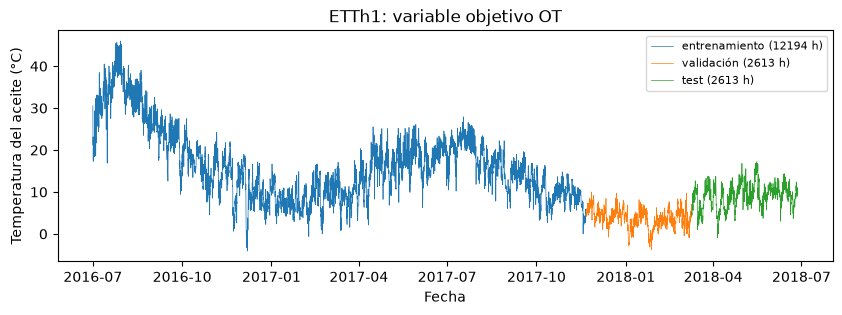

In [3]:
n = len(df)
fin_train, fin_val = int(n * 0.70), int(n * 0.85)
partes = {"entrenamiento": df.iloc[:fin_train], "validación": df.iloc[fin_train:fin_val], "test": df.iloc[fin_val:]}

escalador = MinMaxScaler().fit(partes["entrenamiento"])
escaladas = {k: escalador.transform(v).astype("float32") for k, v in partes.items()}   # OT es la última columna
rango_ot = escalador.data_range_[-1]                      # para pasar errores a °C

fig, ax = plt.subplots(figsize=(10, 3))
for nombre, parte in partes.items():
    ax.plot(parte.index, parte["OT"], lw=0.5, label=f"{nombre} ({len(parte)} h)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Temperatura del aceite (°C)"); ax.set_title("ETTh1: variable objetivo OT")
ax.legend(fontsize=8)
plt.show()

La temperatura del aceite sigue un ciclo anual (máximo de 46 °C en el verano de 2016) y oscila mucho de una hora a otra. Por el orden cronológico, el entrenamiento va de julio de 2016 a noviembre de 2017, la validación cubre el invierno (de −3,7 a 10 °C) y el test la primavera de 2018 (de −0,9 a 17,2 °C). Evaluamos, por tanto, en periodos más tranquilos que buena parte del entrenamiento: el cambio medio de una hora a la siguiente es de 0,69 °C en entrenamiento y de 0,42–0,45 °C en validación y test. Es habitual en series reales y explica que el error de validación pueda ser menor que el de entrenamiento (4.2).

### 3.2. Ventanas deslizantes y líneas base

La función `ventanas` convierte una matriz $(T, D)$ en entradas $(N, L, D)$ y objetivos $(N, H)$ de la columna `OT`. Empezamos con un paso ($H=1$) y $L=24$ horas de historia.

In [4]:
def ventanas(datos, columnas, L, H=1):
    """datos: array (T, 7) escalado. Devuelve X (N, L, len(columnas)) e y (N, H) de OT."""
    idx = range(L, len(datos) - H + 1)
    X = np.stack([datos[i - L:i, columnas] for i in idx])
    y = np.stack([datos[i:i + H, -1] for i in idx])
    return torch.from_numpy(X), torch.from_numpy(y)

def metricas(pred, y):
    """RMSE y MAE en °C (los errores escalados se multiplican por el rango de OT)."""
    error = (pred - y) * rango_ot
    return {"RMSE (°C)": error.pow(2).mean().sqrt().item(), "MAE (°C)": error.abs().mean().item()}

SOLO_OT, TODAS = [6], list(range(7))
X_tr, y_tr = ventanas(escaladas["entrenamiento"], SOLO_OT, 24)
X_va, y_va = ventanas(escaladas["validación"], SOLO_OT, 24)
X_te, y_te = ventanas(escaladas["test"], SOLO_OT, 24)
print("X:", tuple(X_tr.shape), "y:", tuple(y_tr.shape), "| validación", tuple(X_va.shape), "| test", tuple(X_te.shape))

resultados = {"Persistencia (último valor)": metricas(X_te[:, -1, :1], y_te),
              "Media de las últimas 24 h": metricas(X_te[:, :, :1].mean(1), y_te)}
pd.DataFrame(resultados).T.round(3)

X: (12170, 24, 1) y: (12170, 1) | validación (2589, 24, 1) | test (2589, 24, 1)


,RMSE (°C),MAE (°C)
Persistencia (último valor),0.658,0.444
Media de las últimas 24 h,1.557,1.126


Con 24 horas de historia hay 12 170 ventanas de entrenamiento y 2 589 de validación y de test (en cada parte se pierden las 24 primeras horas). Repetir el último valor da un RMSE de **0,658 °C**: de una hora a la siguiente la temperatura cambia poco, y esa es la cifra a batir. La media de las últimas 24 horas es mucho peor (1,557 °C) porque suaviza demasiado.

### 3.3. RNN, LSTM y GRU

Un único modelo para las tres celdas: capa recurrente con 64 unidades ocultas y `batch_first=True` (entrada `(N, L, D)`), y una capa lineal sobre el último estado oculto. Entrenamos con Adam, recorte del gradiente y parada temprana (paciencia 5) sobre el error de validación, quedándonos con los mejores pesos. Como las diferencias pueden ser pequeñas, repetimos cada celda con **3 semillas**.

In [5]:
class Recurrente(nn.Module):
    def __init__(self, celda, n_entradas, ocultas=64, H=1):
        super().__init__()
        self.rnn = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[celda](n_entradas, ocultas, batch_first=True)
        self.salida = nn.Linear(ocultas, H)

    def forward(self, x):                                 # x: (N, L, D)
        h, _ = self.rnn(x)                                # h: (N, L, ocultas), un estado por paso
        return self.salida(h[:, -1])                      # último estado -> (N, H)

def predecir(modelo, X):
    modelo.eval()
    with torch.no_grad():
        return torch.cat([modelo(X[i:i + 4096].to(device)).cpu() for i in range(0, len(X), 4096)])

def entrenar(modelo, X, y, X_val, y_val, semilla, epocas=40, paciencia=5, lr=1e-3):
    modelo.to(device)
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    cargador = DataLoader(TensorDataset(X, y), batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(semilla))
    mejor, mejores_pesos, sin_mejora = float("inf"), None, 0
    for epoca in range(epocas):
        modelo.train()
        for xb, yb in cargador:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            F.mse_loss(modelo(xb), yb).backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)      # evita la explosión del gradiente
            opt.step()
        error_val = F.mse_loss(predecir(modelo, X_val), y_val).item()
        if error_val < mejor:
            mejor, mejores_pesos, sin_mejora = error_val, copy.deepcopy(modelo.state_dict()), 0
        else:
            sin_mejora += 1
            if sin_mejora == paciencia:
                break
    modelo.load_state_dict(mejores_pesos)
    modelo.epocas = epoca + 1
    return modelo

def comparar(celdas, columnas, semillas=(0, 1, 2), **datos):
    filas, modelos = [], {}
    for celda in celdas:
        for s in semillas:
            torch.manual_seed(s)
            inicio = time.time()
            m = modelos[celda, s] = entrenar(Recurrente(celda, len(columnas)), datos["X"], datos["y"], datos["X_val"], datos["y_val"], semilla=s)
            filas.append({"modelo": celda, "semilla": s, "parámetros": sum(p.numel() for p in m.parameters()),
                          "épocas": m.epocas, "segundos": time.time() - inicio, **metricas(predecir(m, datos["X_test"]), datos["y_test"])})
    return pd.DataFrame(filas), modelos

uni, modelos_uni = comparar(["RNN", "LSTM", "GRU"], SOLO_OT, X=X_tr, y=y_tr, X_val=X_va, y_val=y_va, X_test=X_te, y_test=y_te)
tabla_uni = uni.groupby("modelo", sort=False).agg(parámetros=("parámetros", "first"), épocas=("épocas", "mean"), segundos=("segundos", "mean"),
                                      RMSE_media=("RMSE (°C)", "mean"), RMSE_desv=("RMSE (°C)", "std"), MAE_media=("MAE (°C)", "mean")).round(3)
tabla_uni

,parámetros,épocas,segundos,RMSE_media,RMSE_desv,MAE_media
modelo,,,,,,
RNN,4353,20.333,8.793,0.659,0.005,0.446
LSTM,17217,28.667,13.280,0.665,0.007,0.456
GRU,12929,20.333,9.120,0.674,0.036,0.460


In [6]:
# ¿En qué se diferencian las predicciones de las redes de la persistencia?
for celda in ["RNN", "LSTM", "GRU"]:
    distancia = ((predecir(modelos_uni[celda, 0], X_te) - X_te[:, -1, :1]) * rango_ot).abs().mean().item()
    print(f"{celda}: diferencia media con la predicción 'último valor' = {distancia:.3f} °C")

RNN: diferencia media con la predicción 'último valor' = 0.049 °C
LSTM: diferencia media con la predicción 'último valor' = 0.164 °C
GRU: diferencia media con la predicción 'último valor' = 0.248 °C


**Ninguna celda bate a la persistencia**: la RNN simple queda en 0,659 °C (prácticamente lo mismo que repetir el último valor, 0,658), la LSTM en 0,665 y la GRU en 0,674, con una desviación entre semillas de 0,005 a 0,036 °C. Las tres son equivalentes entre sí y con la línea base. De hecho, han aprendido algo muy parecido a copiar el último valor: la predicción de la RNN se separa de él solo 0,049 °C de media (0,16 la LSTM y 0,25 la GRU).

A un paso y con datos horarios, la temperatura casi no se puede predecir mejor que con su valor actual. La ventaja de la LSTM (17 217 parámetros) y la GRU (12 929) sobre la RNN (4 353) está en las dependencias largas, que aquí no hacen falta. Sin la línea base habríamos dado por bueno un RMSE de 0,66 °C sin saber que no aporta nada.

### 3.4. Varias variables de entrada

Ahora cada paso de la ventana lleva las 7 variables ($D=7$): las seis cargas y la propia temperatura. El objetivo sigue siendo `OT`.

In [7]:
X_tr7, _ = ventanas(escaladas["entrenamiento"], TODAS, 24)
X_va7, _ = ventanas(escaladas["validación"], TODAS, 24)
X_te7, _ = ventanas(escaladas["test"], TODAS, 24)
print("X multivariante:", tuple(X_tr7.shape))

multi, _ = comparar(["LSTM", "GRU"], TODAS, X=X_tr7, y=y_tr, X_val=X_va7, y_val=y_va, X_test=X_te7, y_test=y_te)
pd.concat([uni.assign(entrada="solo OT"), multi.assign(entrada="7 variables")]).query("modelo != 'RNN'") \
  .groupby(["modelo", "entrada"], sort=False)[["RMSE (°C)", "MAE (°C)"]].agg(["mean", "std"]).round(3)

X multivariante: (12170, 24, 7)


RMSE (°C)        MAE (°C)       
                        mean    std     mean    std
modelo entrada                                     
LSTM   solo OT         0.665  0.007    0.456  0.008
GRU    solo OT         0.674  0.036    0.460  0.034
LSTM   7 variables     0.663  0.021    0.473  0.022
GRU    7 variables     0.650  0.021    0.456  0.022

Con las 7 variables, la GRU baja a 0,650 °C y la LSTM queda en 0,663, frente a 0,674 y 0,665 solo con `OT`. Son diferencias de 0,002 a 0,024 °C, del orden de la desviación entre semillas (0,021–0,036): están **dentro del ruido**. Las cargas de las horas anteriores apenas ayudan a predecir la temperatura de la hora siguiente cuando ya se conoce la temperatura actual. Lo importante es comprobar que la entrada lleva de verdad las 7 variables: el último eje de `X` debe valer 7.

### 3.5. Predicción a 24 horas con atención

Predecimos las **24 horas siguientes** a la vez (estrategia directa) a partir de $L=96$ horas (4 días). Comparamos con la persistencia y con la **ingenua estacional** (repetir las últimas 24 horas, periodo diario). Añadimos una LSTM con **atención**: el último estado oculto $\mathbf{h}_L$ actúa como consulta, se puntúa cada estado $\mathbf{h}_t$ con un producto escalar, un *softmax* convierte las puntuaciones en pesos $\alpha_t$ y el vector de contexto $\sum_t\alpha_t\mathbf{h}_t$ se une a $\mathbf{h}_L$ antes de la capa de salida:

$$
\alpha_t=\operatorname{softmax}_t\!\left(\frac{(\mathbf{W}\mathbf{h}_t)^\top\mathbf{h}_L}{\sqrt{H}}\right),\qquad \mathbf{c}=\sum_{t=1}^{L}\alpha_t\mathbf{h}_t,\qquad \hat{\mathbf{y}}=\mathbf{W}_y[\mathbf{c},\mathbf{h}_L]+\mathbf{b}_y .
$$

In [8]:
L, H = 96, 24
X_tr96, y_tr24 = ventanas(escaladas["entrenamiento"], SOLO_OT, L, H)
X_va96, y_va24 = ventanas(escaladas["validación"], SOLO_OT, L, H)
X_te96, y_te24 = ventanas(escaladas["test"], SOLO_OT, L, H)

class LSTMAtencion(nn.Module):
    def __init__(self, n_entradas, ocultas=64, H=24):
        super().__init__()
        self.lstm = nn.LSTM(n_entradas, ocultas, batch_first=True)
        self.W = nn.Linear(ocultas, ocultas, bias=False)
        self.salida = nn.Linear(2 * ocultas, H)

    def forward(self, x, devolver_pesos=False):
        h, _ = self.lstm(x)                                               # (N, L, ocultas)
        consulta = h[:, -1]                                               # último estado: (N, ocultas)
        puntuaciones = (self.W(h) @ consulta.unsqueeze(-1)).squeeze(-1) / h.shape[-1] ** 0.5   # (N, L)
        pesos = torch.softmax(puntuaciones, dim=1)                        # suman 1 sobre los L pasos
        contexto = (pesos.unsqueeze(-1) * h).sum(1)                       # (N, ocultas)
        y = self.salida(torch.cat([contexto, consulta], dim=1))
        return (y, pesos) if devolver_pesos else y

modelos_h24, errores_h24 = {}, {}
for nombre, construir in [("LSTM", lambda: Recurrente("LSTM", 1, H=H)), ("LSTM + atención", lambda: LSTMAtencion(1, H=H))]:
    torch.manual_seed(0)
    modelos_h24[nombre] = entrenar(construir(), X_tr96, y_tr24, X_va96, y_va24, semilla=0)

predicciones = {"Persistencia": X_te96[:, -1:, 0].expand(-1, H),
                "Ingenua estacional (24 h)": X_te96[:, -24:, 0],
                **{k: predecir(m, X_te96) for k, m in modelos_h24.items()}}
pd.DataFrame({k: metricas(p, y_te24) for k, p in predicciones.items()}).T.round(3)

,RMSE (°C),MAE (°C)
Persistencia,1.999,1.460
Ingenua estacional (24 h),2.298,1.716
LSTM,1.803,1.298
LSTM + atención,1.832,1.337


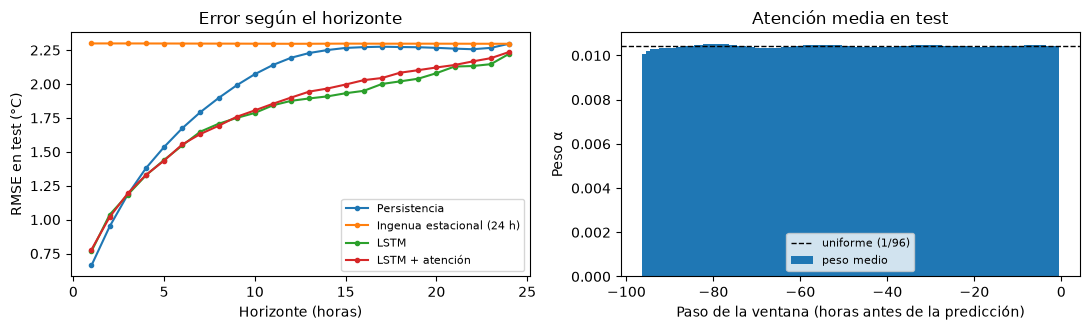

Peso máximo de un paso en cualquier ventana de test: 0.0109 (uniforme = 0.0104)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for nombre, p in predicciones.items():
    rmse_h = ((p - y_te24) * rango_ot).pow(2).mean(0).sqrt()
    axes[0].plot(range(1, H + 1), rmse_h, marker=".", label=nombre)
axes[0].set_xlabel("Horizonte (horas)"); axes[0].set_ylabel("RMSE en test (°C)"); axes[0].set_title("Error según el horizonte")
axes[0].legend(fontsize=8)

with torch.no_grad():
    _, pesos = modelos_h24["LSTM + atención"].eval()(X_te96.to(device), devolver_pesos=True)
pesos = pesos.cpu()
axes[1].bar(range(-L, 0), pesos.mean(0), width=1.0, label="peso medio")
axes[1].axhline(1 / L, color="k", ls="--", lw=1, label=f"uniforme (1/{L})")
axes[1].set_xlabel("Paso de la ventana (horas antes de la predicción)"); axes[1].set_ylabel("Peso α")
axes[1].set_title("Atención media en test"); axes[1].legend(fontsize=8, loc="lower center")
plt.tight_layout()
plt.show()
print(f"Peso máximo de un paso en cualquier ventana de test: {pesos.max():.4f} (uniforme = {1 / L:.4f})")

A 24 horas sí hay margen: la LSTM tiene un RMSE de **1,80 °C** frente a 2,00 de la persistencia (un 10 % menos). El gráfico de la izquierda muestra dónde: en las 3 primeras horas la persistencia es igual o mejor, y a partir de la cuarta la LSTM toma ventaja, con la mayor diferencia (unos 0,3 °C) entre las 10 y las 16 horas. La ingenua estacional (2,30 °C) es la peor: en esta serie la inercia pesa más que el ciclo diario, así que repetir el día anterior no es buena referencia.

La atención **no mejora** a la LSTM (1,83 frente a 1,80 °C, una diferencia del orden del ruido entre semillas de 3.3–3.4), y sus pesos son casi uniformes (gráfico de la derecha): ningún paso recibe más de 0,0109, frente a $1/96=0{,}0104$ si todos pesaran igual. El modelo ha aprendido a usar el contexto como una simple media de la ventana. La atención añade flexibilidad, pero no garantiza ni un resultado mejor ni pesos interpretables; brilla cuando la secuencia es larga y unas pocas posiciones importan mucho más que el resto, como en el texto ([atención y transformers](07-atencion-y-transformers.ipynb)).

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Parámetro | Qué controla | Consejo |
|---|---|---|
| **Celda** (`nn.RNN`, `nn.LSTM`, `nn.GRU`) | Capacidad de memoria | LSTM o GRU por defecto; la RNN simple solo para secuencias muy cortas |
| `hidden_size` | Tamaño del estado oculto | 32–256; más unidades = más memoria y más sobreajuste |
| `num_layers` | Capas recurrentes apiladas | 1–3; con más de una, `dropout` actúa entre capas |
| `dropout` (de la capa recurrente) | Regularización entre capas | Solo tiene efecto si `num_layers > 1` (si no, PyTorch avisa); con una capa, `nn.Dropout` sobre la salida |
| `batch_first` | Orden de los ejes de entrada | `True` para usar `(N, L, D)`; por defecto PyTorch espera `(L, N, D)` (4.2) |
| `bidirectional` | Lectura en los dos sentidos | Solo si la secuencia completa está disponible; nunca para predecir el futuro |
| **Ventana** $L$ | Cuánta historia ve el modelo | Al menos un ciclo estacional (24 h en datos horarios); más larga = más lento y más difícil de aprender |
| **Horizonte** $H$ | Cuántos pasos se predicen | Cuanto más lejos, más error (3.5); compárate con la persistencia y la ingenua estacional |
| **Recorte del gradiente** (`clip_grad_norm_`) | Explosión del gradiente | Norma máxima 0,5–5 |
| **Tasa de aprendizaje** | Velocidad de convergencia | $10^{-3}$ con Adam; con $10^{-4}$ y pocas épocas el modelo aún no ha convergido |

### 4.2. Errores comunes

- **No compararse con una línea base ingenua.** En una serie horaria suave, repetir el último valor ya es muy bueno: aquí ninguna red lo bate a un paso (3.3). Un RMSE "pequeño" en datos escalados (0,012, por ejemplo) no dice nada si no se compara con la persistencia en las mismas unidades.
- **Creer que el modelo es multivariante cuando solo entra una variable.** Si la entrada tiene forma `(N, 24, 1)`, el modelo solo ve `OT`, aunque el escalado se haya hecho con las 7 columnas. Comprueba siempre el último eje de `X` (3.4).
- **Olvidar `batch_first=True` en PyTorch.** Sin él, una entrada `(N, L, D)` se interpreta como `L` secuencias de `N` pasos: la recurrencia recorre **ejemplos distintos del lote** en vez del tiempo. No da error, entrena y hasta da un error razonable, pero la predicción de un ejemplo depende de los demás del lote (demo siguiente).
- **Calcular mal las métricas a varios pasos.** El RMSE necesita la raíz y el MAE el valor absoluto: sin `abs` los errores positivos y negativos se cancelan y salen MAE **negativos**, un síntoma inequívoco del fallo; sin la raíz se publica un MSE con nombre de RMSE.
- **Dividir o escalar sin respetar el tiempo.** Barajar antes de dividir o ajustar el escalador con toda la serie filtra información del futuro ([series temporales](../04-machine-learning/15-series-temporales.ipynb)).
- **Extrañarse de que la validación tenga menos error que el entrenamiento.** Con *dropout* la pérdida de entrenamiento se calcula con la red "dañada", y en una serie temporal los periodos de validación y test pueden ser más estables que el de entrenamiento (en ETTh1 el cambio medio por hora es 0,69 °C en entrenamiento y 0,42 °C en validación, 3.1). No es un error, pero hay que saber explicarlo.
- **Volver a entrenar un modelo ya entrenado sin querer.** Llamar otra vez al bucle de entrenamiento (o a `fit` en Keras) con el mismo objeto **continúa** desde los pesos actuales: para comparar configuraciones hay que crear el modelo de nuevo.
- **Usar una LSTM bidireccional para predecir.** Leería la secuencia también hacia atrás, lo cual está bien para clasificar un texto completo, pero en predicción solo tiene sentido si toda la ventana es pasado.

#### Demo: `batch_first` olvidado

In [10]:
torch.manual_seed(0)
lstm_mal = nn.LSTM(1, 8)                                  # sin batch_first: espera (L, N, D)
lstm_bien = nn.LSTM(1, 8, batch_first=True)
lstm_bien.load_state_dict(lstm_mal.state_dict())          # mismos pesos

lote = X_te[:32]                                          # (32, 24, 1)
for nombre, capa in [("sin batch_first", lstm_mal), ("batch_first=True", lstm_bien)]:
    with torch.no_grad():
        salida_lote = capa(lote)[0][:, -1]                # "último paso" de cada ejemplo, calculado en el lote
        salida_sola = capa(lote[5:6])[0][:, -1]           # el ejemplo 5 calculado solo
    print(f"{nombre:>16}: forma de la salida {tuple(capa(lote)[0].shape)} | "
          f"¿el ejemplo 5 da lo mismo solo que en el lote? {torch.allclose(salida_lote[5], salida_sola[0], atol=1e-6)}")

 sin batch_first: forma de la salida (32, 24, 8) | ¿el ejemplo 5 da lo mismo solo que en el lote? False
batch_first=True: forma de la salida (32, 24, 8) | ¿el ejemplo 5 da lo mismo solo que en el lote? True


Las dos capas tienen los mismos pesos y la salida tiene la misma forma, así que nada avisa del problema. Sin `batch_first`, la capa toma los 32 ejemplos como 32 pasos de tiempo y las 24 horas como 24 secuencias: el estado oculto pasa **de un ejemplo al siguiente**, y la predicción del ejemplo 5 cambia según qué otros ejemplos haya en el lote (con `shuffle=True`, en cada época). Con `batch_first=True` cada ejemplo es independiente.

## 5. Comparación con métodos relacionados

| Método | Memoria a largo plazo | Paralelizable en el tiempo | Datos necesarios | Cuándo usarlo |
|---|---|---|---|---|
| **Ingenuos** (persistencia, estacional) | — | Sí | Ninguno | Siempre, como línea base |
| **[ARIMA / SARIMA](../04-machine-learning/15-series-temporales.ipynb)** | Según los órdenes elegidos | — | Pocos | Series cortas, univariantes, interpretables |
| **[Modelos de ML con retardos](../04-machine-learning/15-series-temporales.ipynb)** (random forest, *boosting*) | Solo los retardos que se construyan | Sí | Medios | Datos tabulares con variables externas; muy competitivos |
| **RNN simple** | Baja (gradiente que se desvanece) | No | Medios | Secuencias muy cortas, fines didácticos |
| **LSTM / GRU** | Media–alta (puertas) | No | Medios | Series temporales y secuencias cortas o medias; modelos ligeros |
| **CNN 1D / TCN** | Según el campo receptivo | Sí | Medios | Patrones locales; entrenamiento rápido |
| **[Transformers](07-atencion-y-transformers.ipynb)** | Alta (atención a todos los pasos) | Sí | Muchos | Texto, secuencias largas, grandes volúmenes de datos |

## 6. Referencias

### Fuentes

- Zhou, H., Zhang, S., Peng, J., Zhang, S., Li, J., Xiong, H. y Zhang, W. (2021). «Informer: beyond efficient transformer for long sequence time-series forecasting». *Proceedings of the AAAI Conference on Artificial Intelligence*, 35(12), 11106–11115. Origen de ETTh1, descargado del repositorio [ETDataset](https://github.com/zhouhaoyi/ETDataset).
- PyTorch: [`nn.RNN`](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html), [`nn.LSTM`](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html), [`nn.GRU`](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html) y [`clip_grad_norm_`](https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html). scikit-learn: [`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html).

### Para saber más

- Hochreiter, S. y Schmidhuber, J. (1997). [«Long short-term memory»](https://doi.org/10.1162/neco.1997.9.8.1735). *Neural Computation*, 9(8), 1735–1780. El artículo original de la LSTM y del problema del gradiente que se desvanece.
- Goodfellow, I., Bengio, Y. y Courville, A. (2016). [*Deep Learning*](https://www.deeplearningbook.org/). MIT Press. El capítulo 10 (modelado de secuencias: redes recurrentes y recursivas) desarrolla todo lo visto aquí.